<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/CNN_workshop/blob/main/Notebooks/LeNet5.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

# MNIST digit recognition using LeNet-5 model

This example implements the LeNet-5 architecture to classify images of handwritten digits. It uses the MNIST database (http://yann.lecun.com/exdb/lenet/), which contains 28x28 pixel images of 10 digit classes, corresponding to the numbers 0 through 9.


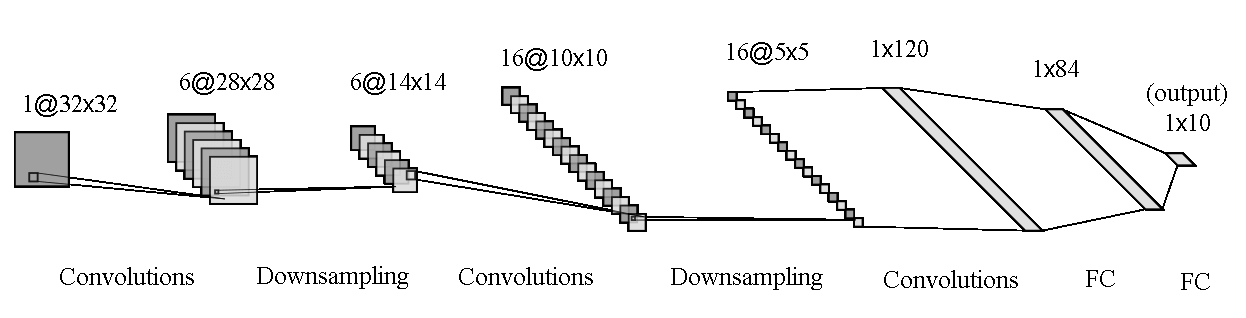

In [ ]:
# Change: Runtime to GPU for faster training

In [ ]:
# Check GPU details
!nvidia-smi

In [ ]:
#@title Load necessary libraries
import numpy as np                                                    # Numerical array operations
import matplotlib.pyplot as plt                                       # Data plotting/visualization
import tensorflow as tf                                               # Deep learning
from sklearn.model_selection import train_test_split                  # Data split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Performance metrics

In [ ]:
#@title Function to shuffle data
def shuffle_data(features, targets):
  id = np.random.permutation(len(targets))
  features = features[id, :]
  targets = targets[id]
  return features, targets

In [ ]:
#@title Download the MNIST database
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
#@title Split data intro training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15, random_state=42)

# Shuffle data
x_train, y_train = shuffle_data(x_train, y_train)
x_val, y_val = shuffle_data(x_val, y_val)
x_test, y_test = shuffle_data(x_test, y_test)

# Check feature and targets shapes
print('\nCheck tensor shapes:\n')
print(f'Shape of training images:   {x_train.shape}')
print(f'Shape of training labels:   {y_train.shape}\n')
print(f'Shape of validation images: {x_val.shape}')
print(f'Shape of validation labels: {y_val.shape}\n')
print(f'Shape of test images:       {x_test.shape}')
print(f'Shape of test labels:       {y_test.shape}\n')

In [ ]:
#@title Image visualization of training images
fig, ax = plt.subplots(nrows=10, ncols=10, figsize=(10,10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
# Loop through each class. Select 10 images of each class to display
print('Training images\n')
for i in range(10):
    # Select images with the current class label
    images = x_train[y_train == i]
    # Loop through each image and display
    for j in range(10):
        # Set the current subplot
        ax[i,j].imshow(images[j], cmap='gray')
        ax[i,j].axis('off')
# Show the plot and save the plot image
plt.show()

In [ ]:
#@title Image data preparation for CNN learning

# Transform to deep learning tensor
x_train = x_train.reshape(len(x_train), 28, 28, 1).astype('float32')
x_test = x_test.reshape(len(x_test), 28, 28, 1).astype('float32')
x_val = x_val.reshape(len(x_val), 28, 28, 1).astype('float32')

# Image normalization to the range [0,1]
x_train /= 255.0
x_test /= 255.0
x_val /= 255.0

# Convert label encoding to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
y_val = tf.keras.utils.to_categorical(y_val, 10)

In [ ]:
#@title TO DO: Implement the LeNet-5 model:
#   1. An input layer of size 28x28x1
#   2. A valid convolutional layer with 6 filters of size 5x5 and ReLU activation function
#   3. A max-pooling layer over a 2x2 area
#   4. A valid convolutional layer with 16 filters of size 5x5 and ReLU activation function
#   5. A max pooling layer over a 2x2 area
#   6. A flattening operation
#   7. A fully connected layer with 120 nodes and ReLU activation function
#   8. A fully connected layer with 84 nodes and ReLU activation function
#   9. A softmax layer with 10 output nodes

#------------------------------------------------------------------------------
# Replace these lines which implement a minimal network (which still does okay)
model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1), name='input_layer'),
        tf.keras.layers.Conv2D(filters=1, kernel_size=(3, 3),
                               strides=(1, 1), activation='tanh',
                               padding='valid', name='conv1'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='maxpool1'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=512, activation='tanh', name='fc1'),
        tf.keras.layers.Dense(units=10, activation='softmax', name='softmax')
        ])
#------------------------------------------------------------------------------

# Model description
print('Model summary\n\n')
model.summary()

In [ ]:
#@title Define training setting
# Adam optimizer
adam = tf.keras.optimizers.Adam(learning_rate=0.001)

# Callback for early stopping if validation accuracy does not improve
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
    )

# Compile model
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

In [ ]:
#@title Train the LeNet-5 model
history = model.fit(x_train, y_train, # Training set
                    batch_size=128, # Mini-batch size
                    epochs=50,      # Number of epochs
                    validation_data=(x_val, y_val), # Validation set
                    verbose=2,  # Print training results
                    callbacks=[early_stop] # Early stopping
                    )

In [ ]:
#@title Show training and validation graphs
training_acc = history.history['accuracy']
validation_acc = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs = np.arange(len(training_loss))

plt.figure(figsize=(6, 4))
plt.plot(epochs, training_acc, color='blue', label='Training')
plt.plot(epochs, validation_acc, color = 'green', label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print()

plt.figure(figsize = (6, 4))
plt.plot(epochs, training_loss, color='blue', label='Training')
plt.plot(epochs, validation_loss, color = 'green', label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross-entropy loss')
plt.legend()
plt.show()

In [ ]:
#@title Model prediction on test images
y_pred = model.predict(x_test)
ypp = np.argmax(y_pred, axis=1)
ytt = np.argmax(y_test, axis=1)

ACC = 100*np.mean(ypp == ytt)
print(f"Accuracy: {ACC:.2f}%")

cm = confusion_matrix(ytt, ypp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()

In [ ]:
#@title Image visualization of test images
fig, ax = plt.subplots(nrows=10, ncols=10, figsize=(10,10))
fig.subplots_adjust(hspace=0.5, wspace=0.1)
# Loop through each class. Select 10 images of each class to display
print('Test images\n')
for i in range(10):
    # Select images with the current class label
    idx = ytt == i
    images = x_test[idx]
    y_pred = ypp[idx]
    y_true = ytt[idx]
    # Loop through each image and display
    for j in range(10):
        # Set the current subplot
        ax[i,j].imshow(images[j], cmap='gray')
        ax[i,j].axis('off')
        # Check prediction
        if (y_pred[j] != y_true[j]):
          txt = str(y_pred[j]) + ' - ' + str(y_true[j])
          ax[i,j].set_title(txt, color='red')
        else:
          ax[i,j].set_title(str(y_pred[j]), color='green')
# Show the plot and save the plot image
plt.show()

In [ ]:
#@title Save CNN model in Google drive
from google.colab import drive
drive.mount('/content/drive')
model.save('/content/drive/MyDrive/lenet5.keras')